In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# 1. Data loading and preparation
# Hint: Use transforms.ToTensor and Normalize
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_dataset, test_dataset = random_split(full_dataset, [50000, 10000])

# DataLoader: Remember, this is efficient for larger datasets
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Model definition
class FashionClassifier(nn.Module):
    def __init__(self):
        super(FashionClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)  # Input layer to hidden layer
        self.fc2 = nn.Linear(128, 10)         # Hidden layer to output layer
        self.relu = nn.ReLU()                 # Activation function
        
        pass 

    def forward(self, x):
        # TODO: Define the flow of data through the layers
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = FashionClassifier()

# 3. Optimization and loss function
criterion = nn.CrossEntropyLoss()
# TODO: Choose an optimizer (Adam or SGD) and set the learning rate
optimizer = None 

# 4. Training loop
epochs = 5
loss_history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        # TODO: Implement the training steps:
        # 1. Zero the gradients
        # 2. Forward pass
        # 3. Calculate loss
        # 4. Backward pass
        # 5. Optimizer step
        pass
    
    # avg_loss = ... (calculate average loss and append to list)
    # print(...)

# 5. Visualization
# plt.plot(...)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 1.05MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 9.51MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 33.5MB/s]



Aloitetaan opetus - Learning Rate: 0.01
Epoch 1/5 - Loss: 0.5557
Epoch 2/5 - Loss: 0.4604
Epoch 3/5 - Loss: 0.4367
Epoch 4/5 - Loss: 0.4230
Epoch 5/5 - Loss: 0.4072

Aloitetaan opetus - Learning Rate: 0.001
Epoch 1/5 - Loss: 0.5162
Epoch 2/5 - Loss: 0.3904
Epoch 3/5 - Loss: 0.3538
Epoch 4/5 - Loss: 0.3266
Epoch 5/5 - Loss: 0.3061

Aloitetaan opetus - Learning Rate: 0.0001
Epoch 1/5 - Loss: 0.7739
Epoch 2/5 - Loss: 0.5022
Epoch 3/5 - Loss: 0.4568
Epoch 4/5 - Loss: 0.4311
Epoch 5/5 - Loss: 0.4119


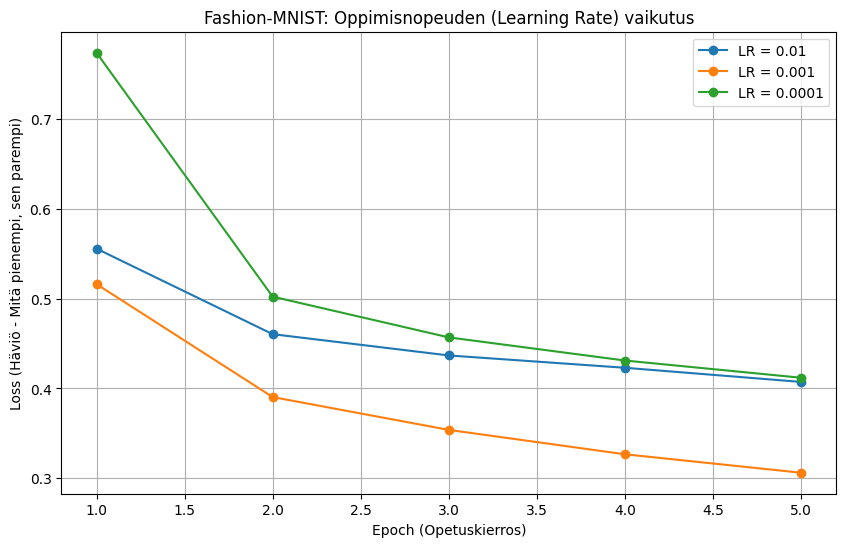

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# 1. Data loading and preparation
# Hint: Use transforms.ToTensor and Normalize
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_dataset, test_dataset = random_split(full_dataset, [50000, 10000])

# DataLoader: Remember, this is efficient for larger datasets
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Model definition
class FashionClassifier(nn.Module):
    def __init__(self):
        super(FashionClassifier, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)  # Input layer to hidden layer
        self.fc2 = nn.Linear(128, 10)         # Hidden layer to output layer
        self.relu = nn.ReLU()                 # Activation function
        
        pass 

    def forward(self, x):
        # TODO: Define the flow of data through the layers
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
    



learning_rates = [0.01, 0.001, 0.0001]
all_loss_histories = {} #tallenneteaan hävikki tänne

for lr in learning_rates:
    print(f"\n=========================================")
    print(f"Aloitetaan opetus - Learning Rate: {lr}")
    print(f"=========================================")

    model = FashionClassifier()  # Uusi malli jokaista oppimisnopeutta varten

    #3. Optimization and loss function
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)  # Käytetään Adam-optimointia

    #4. Training loop
    epochs = 5
    loss_history = [] #tallennetaan tämän kierroksen hävikki tähän listaan

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()             # 1. Zero the gradients
            outputs = model(images)           # 2. Forward pass
            loss = criterion(outputs, labels) # 3. Calculate loss
            loss.backward()                   # 4. Backward pass
            optimizer.step()                  # 5. Optimizer step

            running_loss += loss.item()

        # calculate average loss and append to list
        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
        
    # Tallennetaan tämän kierroksen tulokset talteen dictionaryyn
    all_loss_histories[lr] = loss_history


# 5. Visualization
plt.figure(figsize=(10, 6))

# Piirretään kaikkien kolmen kokeilun viivat samaan kuvaajaan
for lr, history in all_loss_histories.items():
    plt.plot(range(1, epochs + 1), history, label=f'LR = {lr}', marker='o')

plt.xlabel('Epoch (Opetuskierros)')
plt.ylabel('Loss (Häviö - Mitä pienempi, sen parempi)')
plt.title('Fashion-MNIST: Oppimisnopeuden (Learning Rate) vaikutus')
plt.legend()
plt.grid(True)
plt.show()

=== FASHION-MNIST LOPULLINEN MALLI ===

Aloitetaan finaalimallin opetus...
Kierros 1/10 - Keskimääräinen häviö (Loss): 0.5519
Kierros 2/10 - Keskimääräinen häviö (Loss): 0.4116
Kierros 3/10 - Keskimääräinen häviö (Loss): 0.3792
Kierros 4/10 - Keskimääräinen häviö (Loss): 0.3587
Kierros 5/10 - Keskimääräinen häviö (Loss): 0.3477
Kierros 6/10 - Keskimääräinen häviö (Loss): 0.3367
Kierros 7/10 - Keskimääräinen häviö (Loss): 0.3291
Kierros 8/10 - Keskimääräinen häviö (Loss): 0.3201
Kierros 9/10 - Keskimääräinen häviö (Loss): 0.3148
Kierros 10/10 - Keskimääräinen häviö (Loss): 0.3080


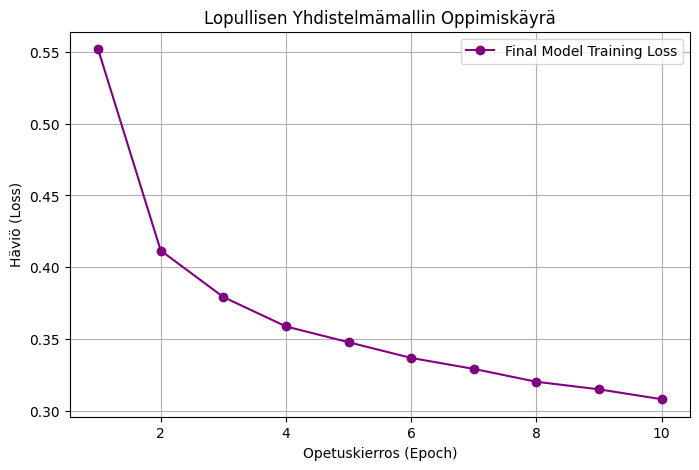


LOPULLISEN MALLIN TARKKUUS TESTIDATALLA: 88.29%


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

print("=== FASHION-MNIST LOPULLINEN MALLI ===")

# ==========================================
# 1. Datan lataus (Rikun paras Batch Size: 64)
# ==========================================
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_dataset, test_dataset = random_split(full_dataset, [50000, 10000])

best_batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False)

# ==========================================
# 2. Mallin rakenne (Arin 2 piilokerrosta)
# ==========================================
class FinalFashionClassifier(nn.Module):
    def __init__(self):
        super(FinalFashionClassifier, self).__init__()
        self.flatten = nn.Flatten() 
        self.fc1 = nn.Linear(28*28, 128) # 1. piilokerros
        self.fc2 = nn.Linear(128, 64)    # 2. piilokerros
        self.fc3 = nn.Linear(64, 10)     # Ulostulokerros (10 luokkaa)
        self.relu = nn.ReLU()            # Aktivointifunktio
        
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

final_model = FinalFashionClassifier()

# ==========================================
# 3. Optimointi (Kim: Adam, Elias: LR 0.001, Reng: Weight Decay 0.001)
# ==========================================
criterion = nn.CrossEntropyLoss()
final_optimizer = optim.Adam(final_model.parameters(), lr=0.001, weight_decay=0.001)

# ==========================================
# 4. Opetussilmukka (Training Loop)
# ==========================================
epochs = 10  # Finaalimallille voi hyvin antaa vähän enemmän kierroksia, esim. 10!
final_loss_history = []

print("\nAloitetaan finaalimallin opetus...")
for epoch in range(epochs):
    final_model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        final_optimizer.zero_grad()             # 1. Nollataan gradientit
        outputs = final_model(images)           # 2. Forward pass
        loss = criterion(outputs, labels)       # 3. Lasketaan virhe
        loss.backward()                         # 4. Backward pass
        final_optimizer.step()                  # 5. Päivitetään painot
        
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    final_loss_history.append(avg_loss)
    print(f"Kierros {epoch+1}/{epochs} - Keskimääräinen häviö (Loss): {avg_loss:.4f}")

# ==========================================
# 5. Finaalimallin Visualisointi
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), final_loss_history, marker='o', color='purple', label='Final Model Training Loss')
plt.xlabel('Opetuskierros (Epoch)')
plt.ylabel('Häviö (Loss)')
plt.title('Lopullisen Yhdistelmämallin Oppimiskäyrä')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 6. LOPULLISEN TARKKUUDEN TESTAUS (Bonuspisteitä varten!)
# ==========================================
final_model.eval() # Asetetaan malli arviointitilaan
correct = 0
total = 0

# Tässä ei tarvita gradientteja, mikä säästää muistia
with torch.no_grad():
    for images, labels in test_loader:
        outputs = final_model(images)
        _, predicted = torch.max(outputs.data, 1) # Valitaan todennäköisin vaateluokka
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\n=========================================")
print(f"LOPULLISEN MALLIN TARKKUUS TESTIDATALLA: {accuracy:.2f}%")
print(f"=========================================")